Dectacting Mice Tail with Different Methods

In [1]:
import os
import pandas as pd
#import plotly.express as px
import cv2 as cv
import argparse
import numpy as np
import time
import statistics
from datetime import datetime
from matplotlib import pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde
from scipy.signal import find_peaks



In [40]:
ruta_carpeta = r'C:\Users\inges\OneDrive - UDIT\src\photoneu\dataset\deeplabcut\labeled-data-ordered'
#ruta_carpeta = r'C:\Users\inges\OneDrive - UDIT\src\photoneu\dataset\movai_4_mice'
#ruta_carpeta = r'C:\Users\inges\OneDrive - UDIT\src\photoneu\dataset\movai_3_mice'

# test 1 frame
# TriMouse
#ruta_imagen = r'/img0734.png'
#ruta_imagen = r'/img1150.png' # 3 overlapping
#ruta_imagen = r'/img0000_1.png'
ruta_imagen = r'/img1075.png'

# 4 mice
#ruta_imagen = r'/240513_3w_073b_076b_f_int_mask_287_jpg.rf.b61bb34b8ed0cab3271de0a6ded8a112.jpg'
# 3 mice
#ruta_imagen = r'/240712_3w_148b_151b_154b_m_rec_1000model_mp4-0217_jpg.rf.42e6e12fa3b10f4d122bf6d31281f10d.jpg'

kernel_3 = cv.getStructuringElement(cv.MORPH_ELLIPSE,(3,3))
kernel_5 = cv.getStructuringElement(cv.MORPH_ELLIPSE,(5,5))
RESIZE_FACTOR = 2.0
MAJOR_DEFECT_THRESHOLD = 12.0 / RESIZE_FACTOR #6.0 5.0 12.0
MIN_AREA = 800
MAX_AREA = 12 * MIN_AREA#2.5 * MIN_AREA
BW_THRES = 63 # min B/W value for threshold
N = 161 # number of images
#N = 242 # frames video_2 video_4
#N = 302 # framse video_3
#N = 1801 # framse video_5
#N = 1801 # framse video_6
# img size original: 640 x 480
normal_size = (480, 640)

# TriMouse
x_crop_min = int(normal_size[1]/19) #50
x_crop_max = int(normal_size[1]/25) # 30
y_crop_min = int(normal_size[0]/20) # 30
y_crop_max = int(normal_size[0]/20) # 16 -- 40

# 3mice dataset
#x_crop_min = int(normal_size[1]/7)#int(normal_size[1]/10) #50
#x_crop_max = int(normal_size[1]/7)#int(normal_size[1]/20) # 30
#y_crop_min = int(normal_size[0]/7)#int(normal_size[0]/16) # 30
#y_crop_max = int(normal_size[0]/5) #int(normal_size[0]/20) # 16 -- 40

SEGMENT_COLORS = [(0,255,0),(0,255,255),(255,255,0),(255,0,255)]


In [5]:
def read_image(i, ruta_carpeta, img_name):  
#    img_base = os.path.basename(img_name)
    img_base = os.path.splitext(img_name)[0]
    img_in = ruta_carpeta + img_name
    e1 = cv.getTickCount()
    frame = cv.imread(img_in)
    h,w,_ = frame.shape
    frame_o = frame[x_crop_min:(h-x_crop_max), y_crop_min:(w-y_crop_max)]
    frame = cv.resize(frame_o, (int(normal_size[1]/RESIZE_FACTOR), int(normal_size[0]/RESIZE_FACTOR))) # frame.shape/2
#     print(frame.shape) # 240 x 320
    e2 = cv.getTickCount()
    t_init_resize = (e2 - e1)/cv.getTickFrequency()
    return frame

In [6]:
def clean_image(frame):
     frame_gray = cv.cvtColor(frame, cv.COLOR_BGR2GRAY)
     frame_norm = cv.normalize(frame_gray, None, alpha = 0, beta = 255, norm_type=cv.NORM_MINMAX)
     frame_blur = cv.medianBlur(frame_norm, 5)
     frame_blur = cv.equalizeHist(frame_blur)
     ret, frame_threshold = cv.threshold( frame_blur, BW_THRES, 255, cv.THRESH_BINARY_INV ) #+ cv.THRESH_OTSU )
#     frame_threshold = cv.adaptiveThreshold(frame_blur, 255, 
#                                               cv.ADAPTIVE_THRESH_GAUSSIAN_C, 
#                                               cv.THRESH_BINARY_INV, 11, 2)
     return frame_threshold     


In [ ]:
def erode_image(frame):
#     frame_erode = cv.morphologyEx(frame, cv.MORPH_DILATE, kernel_3, iterations = 4)  
     opening = cv.morphologyEx(frame, cv.MORPH_OPEN, kernel_3, iterations = 6)

     return opening
    

    

The following methods fail and have to be degugged

In [12]:

def remove_tail_by_thickness(img, tail_residual_rate=0.5,
                             min_tail_branch_length_px=10,
                             debug=False):
    """
    Elimina/reduce la cola basándose en local thickness + morfología.
    tail_residual_rate: 0.0 -> cola eliminada; 1.0 -> cola completa.
    """
    assert 0.0 <= tail_residual_rate <= 1.0

    contours, _ = cv.findContours(img, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_NONE)
    if len(contours) == 0:
        return np.zeros_like(img)
    #    contours, _ = cv.findContours(image, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)
    for i, cnt in enumerate(contours):
    #    main_contour = max(contours, key=cv.contourArea)
        mask = np.zeros_like(img, dtype=np.uint8)
        cv.drawContours(mask, [cnt], -1, 255, -1)

        if tail_residual_rate >= 0.999:
            # pedir todo: no tocar
            return mask

        # --- Distance transform (local radius) ---
        # distanceTransform requiere foreground=255
        dist_map = cv.distanceTransform((mask>0).astype(np.uint8), cv.DIST_L2, 5)
        # (dist_map está en píxeles, float32) -> radius local

        # --- Skeleton (medial axis) ---
        try:
            # si existe ximgproc.thinning, usarlo (más rápido)
            thin = cv.ximgproc.thinning(mask)
            skel = (thin > 0).astype(np.uint8)
        except Exception:
            # fallback a morphological skeletonize
            skel = skeletonize(mask)

        # si no hay esqueleto válido, devolvemos máscara original
        if np.count_nonzero(skel) == 0:
            if debug:
                print("No skeleton found.")
            return mask

        # --- Obtener endpoints y seguir ramas ---
        endpoints = get_skeleton_endpoints(skel)
        if len(endpoints) == 0:
            if debug:
                print("No endpoints found in skeleton.")
            return mask 

        branches = []
        for ep in endpoints:
            branch_coords = follow_skeleton_from(ep, skel, max_steps=500)
            if len(branch_coords) >= min_tail_branch_length_px:
                # obtener radios (dist_map) a lo largo de los primeros N puntos de la rama
                branches.append(branch_coords)

        if len(branches) == 0:
            if debug:
                print("No valid branches found in skeleton.")
            return mask

        # --- Identificar la rama que probablemente es la cola ---
        # criterio: rama con menor media de radius (tail es delgada)
        branch_stats = []
        for b in branches:
            radii = [dist_map[y,x] for (y,x) in b]
            mean_r = float(np.mean(radii)) if len(radii)>0 else np.inf
            branch_stats.append((mean_r, len(b), b))
        # elegir la rama con menor mean_r (más delgada)
        branch_stats.sort(key=lambda x: x[0])
        mean_radius_tail, tail_len, tail_branch = branch_stats[0]

        # si por alguna razón la rama detectada es muy ancha -> no se considera cola
        # (umbral configurable)
        if mean_radius_tail > np.percentile(dist_map[mask>0], 50):  # si es >= mediana, no es cola
            # posible que no haya cola identificable: devolvemos mask
            if debug:
                print("No thin branch found (mean radius too large).")
            return mask

        # --- Reconstruir región de cola a partir de la rama (dibujar discos alrededor de cada punto) ---
        H, W = mask.shape
        tail_region = np.zeros_like(mask, dtype=np.uint8)
        for (y,x) in tail_branch:
            r = int(np.ceil(dist_map[y,x]))
            if r <= 0:
                r = 1
            # dibujar círculo (relleno)
            cv.circle(tail_region, (int(x), int(y)), r, 255, -1)

        # recortar a la máscara original (por si alguna parte salía fuera)
        tail_region = cv.bitwise_and(tail_region, mask)

        # cuerpo = máscara sin la región de cola original
        body_mask = cv.bitwise_and(mask, cv.bitwise_not(tail_region))

        # --- Calcular cuánto erosionar la cola para alcanzar tail_residual_rate ---
        # mean_radius_tail = promedio de radios en la rama (ya calculado)
        target_mean_radius = mean_radius_tail * tail_residual_rate
        # número aproximado de píxeles a erosionar (por radio): 
        # si r = 0 => eliminar (erode iterations = ceil(mean_radius_tail))
        erode_pixels = int(np.ceil(max(0.0, mean_radius_tail - target_mean_radius)))

        if erode_pixels <= 0:
            # no hace falta tocar la cola
            new_tail = tail_region.copy()
        else:
            # kernel pequeño (3x3) aplicado erode_pixels veces para reducir grosor gradualmente
            kernel3 = cv.getStructuringElement(cv.MORPH_ELLIPSE, (3,3))
            # erosionar la región de cola original (solo actúa en la cola)
            new_tail = cv.erode(tail_region, kernel3, iterations=erode_pixels)
            # limpieza: abrir para quitar pequeños artefactos
            new_tail = cv.morphologyEx(new_tail, cv.MORPH_OPEN, kernel3, iterations=1)
            # opcional: dilatar 1 vez para suavizar borde sin recuperar mucho grosor
            if erode_pixels > 1:
                new_tail = cv.dilate(new_tail, kernel3, iterations=1)

        # --- Combinar cuerpo + nueva cola reducida ---
        result_mask = cv.bitwise_or(body_mask, new_tail)
        plt.imshow(cv.cvtColor(result_mask, cv.COLOR_BGR2RGB))
        plt.show()
#        if debug:
#            # retornar también mapas para diagnóstico
#            return {
#                "result_mask": result_mask,
#                "mask": mask,
#                "dist_map": dist_map,
#                "skeleton": (skel*255).astype(np.uint8),
#                "tail_region_original": tail_region,
#                "tail_region_reduced": new_tail,
#                "selected_branch_length": tail_len,
#                "selected_branch_mean_radius": mean_radius_tail,
#                "erode_pixels": erode_pixels
#            }


In [ ]:
def skeletonize(mask):
    """Skeletonization morphological (fallback si no hay ximgproc)."""
    img = (mask > 0).astype(np.uint8) * 255
    skel = np.zeros_like(img)
    kernel = cv.getStructuringElement(cv.MORPH_CROSS, (3,3))
    while True:
        eroded = cv.erode(img, kernel)
        opened = cv.dilate(eroded, kernel)
        temp = cv.subtract(img, opened)
        skel = cv.bitwise_or(skel, temp)
        img = eroded
        if cv.countNonZero(img) == 0:
            break
    return (skel > 0).astype(np.uint8)  # 0/1 skeleton

def get_skeleton_endpoints(skel):
    """Devuelve lista de (y,x) endpoints del skeleton (vecinos == 1)."""
    # kernel que cuenta vecinos 8-conectados
    kernel = np.ones((3,3), dtype=np.uint8)
    neigh = cv.filter2D(skel.astype(np.uint8), -1, kernel)
    # para cada píxel skeleton: número de vecinos = neigh - 1 (restar el propio)
    neigh_count = neigh * skel - skel
    endpoints = np.argwhere((skel == 1) & (neigh_count == 1))
    return [tuple(p) for p in endpoints]  # (y,x)

def follow_skeleton_from(endpoint, skel, max_steps=200):
    """
    Recorre el esqueleto desde un endpoint hacia el interior hasta
    llegar a una unión (degree != 2) o hasta max_steps.
    Devuelve lista ordenada de coords (y,x).
    """
    H, W = skel.shape
    visited = set()
    path = []
    curr = endpoint
    visited.add(curr)
    path.append(curr)
    # offsets 8-neighbors
    neigh_offsets = [(-1,-1),(-1,0),(-1,1),(0,-1),(0,1),(1,-1),(1,0),(1,1)]
    for _ in range(max_steps):
        y,x = curr
        # find neighbors on skeleton not visited
        neighbors = []
        for dy,dx in neigh_offsets:
            ny, nx = y+dy, x+dx
            if 0 <= ny < H and 0 <= nx < W and skel[ny,nx]:
                if (ny,nx) not in visited:
                    neighbors.append((ny,nx))
        if len(neighbors) == 0:
            break
        # ideally only 1 neighbor (path), if >1 then junction reached: stop
        if len(neighbors) > 1:
            # choose one neighbor arbitrarily (but we stop after adding it)
            next_px = neighbors[0]
            path.append(next_px)
            break
        # exactly 1 neighbor -> continue
        next_px = neighbors[0]
        visited.add(next_px)
        path.append(next_px)
        curr = next_px
    return path  # lista (y,x)


In [ ]:

def remove_tail(img, body_integrity=0.8, tail_residual_rate=0.05):
    """
    Remove the tail from a mouse top-view image.
    
    Parameters:
        img : np.ndarray
            Input image (BGR)
        body_integrity : float
            Fraction of the main blob area to keep (0-1)
        tail_residual_rate : float
            Maximum allowed fraction of residual tail area (0-1)
    
    Returns:
        body_mask : np.ndarray
            Binary mask of mouse body without tail
    """
    # --- Preprocessing ---
#    gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
#    gray_eq = cv.equalizeHist(gray)
#    thresh = cv.adaptiveThreshold(gray_eq, 255,
#                                   cv.ADAPTIVE_THRESH_GAUSSIAN_C,
#                                   cv.THRESH_BINARY_INV, 51, 5)
#    
    # --- Largest contour detection ---
    contours, _ = cv.findContours(img, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_NONE)
    if len(contours) == 0:
        return np.zeros_like(img)
    #    contours, _ = cv.findContours(image, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)
    for i, contour in enumerate(contours):
#    main_contour = max(contours, key=cv.contourArea)
        original_area = cv.contourArea(contour)

        # --- Approximate ellipse for orientation ---
        if len(contour) >= 5:
            ellipse = cv.fitEllipse(contour)
            (center, axes, angle) = ellipse
            major_axis = max(axes)
        else:
            x, y, w, h = cv.boundingRect(contour)
            center = (x + w/2, y + h/2)
            major_axis = max(w, h)
            angle = 0

        # --- Create binary mask ---
        mask = np.zeros_like(img)
        cv.drawContours(mask, [contour], -1, 255, -1)
#        plt.imshow(cv.cvtColor(mask, cv.COLOR_BGR2RGB))
 #       plt.show()
        
        # --- Distance transform from center (vectorized) ---
        yy, xx = np.indices(mask.shape)
        dist_map = np.sqrt((xx - center[0])**2 + (yy - center[1])**2)

        # Threshold distance map according to body_integrity
        max_dist = dist_map[mask > 0].max()
        cut_dist = max_dist * body_integrity
        body_mask = np.zeros_like(mask)
        body_mask[(mask > 0) & (dist_map <= cut_dist)] = 255
        print(f"Initial body area: {np.sum(body_mask)/255} ({(np.sum(body_mask)/255) / original_area:.2%})")
        plt.imshow(cv.cvtColor(mask, cv.COLOR_BGR2RGB))
        plt.show()

        # --- Optional: clean small tail residues ---
        residual_area = np.sum(mask - body_mask)/255

    #    if residual_area / original_area > tail_residual_rate:
        print(f"Initial residual area: {residual_area} ({residual_area / original_area:.2%})")
        while residual_area / original_area > tail_residual_rate:
            print(f"Residual area {residual_area} too high, eroding further...")
            body_mask = cv.morphologyEx(body_mask, cv.MORPH_DILATE, kernel_3, iterations = 1)  
            body_mask = cv.morphologyEx(body_mask, cv.MORPH_OPEN, kernel_3, iterations = 1)
            residual_area = np.sum(mask - body_mask)/255
        plt.imshow(cv.cvtColor(body_mask, cv.COLOR_BGR2RGB))
        plt.show()

#    return body_mask


In [ ]:

def remove_tail(img, body_integrity=0.8, tail_residual_rate=0.05):
    """
    Remove the tail from a mouse top-view image.
    
    Parameters:
        img : np.ndarray
            Input image (BGR)
        body_integrity : float
            Fraction of the main blob area to keep (0-1)
        tail_residual_rate : float
            Maximum allowed fraction of residual tail area (0-1)
    
    Returns:
        body_mask : np.ndarray
            Binary mask of mouse body without tail
    """
    # --- Preprocessing ---
#    gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
#    gray_eq = cv.equalizeHist(gray)
#    thresh = cv.adaptiveThreshold(gray_eq, 255,
#                                   cv.ADAPTIVE_THRESH_GAUSSIAN_C,
#                                   cv.THRESH_BINARY_INV, 51, 5)
#    
    # --- Largest contour detection ---
    contours, _ = cv.findContours(img, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_NONE)
    if len(contours) == 0:
        return np.zeros_like(img)
    #    contours, _ = cv.findContours(image, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)
    for i, contour in enumerate(contours):
#    main_contour = max(contours, key=cv.contourArea)
        original_area = cv.contourArea(contour)

        # --- Approximate ellipse for orientation ---
        if len(contour) >= 5:
            ellipse = cv.fitEllipse(contour)
            (center, axes, angle) = ellipse
            major_axis = max(axes)
        else:
            x, y, w, h = cv.boundingRect(contour)
            center = (x + w/2, y + h/2)
            major_axis = max(w, h)
            angle = 0

        # --- Create binary mask ---
        mask = np.zeros_like(img)
        cv.drawContours(mask, [contour], -1, 255, -1)
#        plt.imshow(cv.cvtColor(mask, cv.COLOR_BGR2RGB))
 #       plt.show()
        
        # --- Distance transform from center (vectorized) ---
        yy, xx = np.indices(mask.shape)
        dist_map = np.sqrt((xx - center[0])**2 + (yy - center[1])**2)

        # Threshold distance map according to body_integrity
        max_dist = dist_map[mask > 0].max()
        cut_dist = max_dist * body_integrity
        body_mask = np.zeros_like(mask)
        body_mask[(mask > 0) & (dist_map <= cut_dist)] = 255
        print(f"Initial body area: {np.sum(body_mask)/255} ({(np.sum(body_mask)/255) / original_area:.2%})")
        plt.imshow(cv.cvtColor(mask, cv.COLOR_BGR2RGB))
        plt.show()

        # --- Optional: clean small tail residues ---
        residual_area = np.sum(mask - body_mask)/255

    #    if residual_area / original_area > tail_residual_rate:
        print(f"Initial residual area: {residual_area} ({residual_area / original_area:.2%})")
        while residual_area / original_area > tail_residual_rate:
            print(f"Residual area {residual_area} too high, eroding further...")
            body_mask = cv.morphologyEx(body_mask, cv.MORPH_DILATE, kernel_3, iterations = 1)  
            body_mask = cv.morphologyEx(body_mask, cv.MORPH_OPEN, kernel_3, iterations = 1)
            residual_area = np.sum(mask - body_mask)/255
        plt.imshow(cv.cvtColor(body_mask, cv.COLOR_BGR2RGB))
        plt.show()

#    return body_mask


In [ ]:

def remove_tail(img, tail_residual_rate=0.5):
    # --- Largest contour detection ---
    contours, _ = cv.findContours(img, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_NONE)
    if len(contours) == 0:
        return np.zeros_like(img)
    #    contours, _ = cv.findContours(image, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)
    for i, contour in enumerate(contours):
#    main_contour = max(contours, key=cv.contourArea)
        original_area = cv.contourArea(contour)

        # --- Approximate ellipse for orientation ---
        if len(contour) >= 5:
            ellipse = cv.fitEllipse(contour)
            (center, axes, angle) = ellipse
            major_axis = max(axes)
        else:
            x, y, w, h = cv.boundingRect(contour)
            center = (x + w/2, y + h/2)
            major_axis = max(w, h)
            angle = 0

        # --- Create binary mask ---
        mask = np.zeros_like(img)
        cv.drawContours(mask, [contour], -1, 255, -1)
#        plt.imshow(cv.cvtColor(mask, cv.COLOR_BGR2RGB))
     #       plt.show()

        # --- Project contour points on major axis ---
        # Rotation matrix for ellipse angle
        theta = np.deg2rad(angle)
        R = np.array([[np.cos(theta), -np.sin(theta)],
                      [np.sin(theta),  np.cos(theta)]])

        pts = contour.reshape(-1,2).astype(np.float32)
        # Center to origin, rotate
        pts_rot = (pts - center) @ R
        # Find extreme points along major axis (x in rotated frame)
        xmin_idx = np.argmin(pts_rot[:,0])
        xmax_idx = np.argmax(pts_rot[:,0])
        head_tip = tuple(pts[xmin_idx])
        tail_tip = tuple(pts[xmax_idx])

        # --- Determine which is tail vs head ---
        # measure local thickness (distance between opposite contour points in y-direction)
        y_range_head = pts_rot[np.abs(pts_rot[:,0]-pts_rot[xmin_idx,0]) < 5, 1].ptp()
        y_range_tail = pts_rot[np.abs(pts_rot[:,0]-pts_rot[xmax_idx,0]) < 5, 1].ptp()
        if y_range_head > y_range_tail:
            # swap if misclassified
            head_tip, tail_tip = tail_tip, head_tip

        # --- Distance map from tail tip ---
        yy, xx = np.indices(mask.shape)
        dist_map = np.sqrt((xx - tail_tip[0])**2 + (yy - tail_tip[1])**2)

        # Max dist from tail to contour (approx tail length + body)
        max_dist = dist_map[mask > 0].max()

        # Cut distance based on tail_residual_rate
        cut_dist = max_dist * tail_residual_rate

        # Keep everything except the last fraction of the tail
        body_mask = np.zeros_like(mask)
        body_mask[(mask > 0) & (dist_map >= (max_dist - cut_dist))] = 255

        plt.imshow(cv.cvtColor(body_mask, cv.COLOR_BGR2RGB))
        plt.show()

    #    return body_mask


In [ ]:
def remove_tail_convex(img, tail_residual_rate=0.5):
    contours, _ = cv.findContours(img, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_NONE)
    if len(contours) == 0:
        return np.zeros_like(img)
    #    contours, _ = cv.findContours(image, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)
    for i, main_contour in enumerate(contours):
    #    main_contour = max(contours, key=cv.contourArea)
        original_area = cv.contourArea(main_contour)
        
        # --- Convex Hull & Defects ---
        hull = cv.convexHull(main_contour, returnPoints=False)
        if hull is None or len(hull) < 3:
            return np.zeros_like(img)
        
        defects = cv.convexityDefects(main_contour, hull)
        
        # --- Find deepest defect (likely where tail starts) ---
        cut_point = None
        if defects is not None and defects.shape[0] > 0:
            max_depth = 0
            for i in range(defects.shape[0]):
                s, e, f, depth = defects[i, 0]
                far = tuple(main_contour[f][0])
                if depth > max_depth:
                    max_depth = depth
                    cut_point = far
        
        # --- Create mask of the body (cut at defect) ---
        mask = np.zeros_like(img)
        cv.drawContours(mask, [main_contour], -1, 255, -1)
        
        if cut_point is not None:
            # distancia de cada píxel al cut_point
            yy, xx = np.indices(mask.shape)
            dist_map = np.sqrt((xx - cut_point[0])**2 + (yy - cut_point[1])**2)
            
            # definimos un corte relativo al body_integrity
            max_dist = dist_map[mask > 0].max()
            cut_dist = max_dist * tail_residual_rate
            
            body_mask = np.zeros_like(mask)
            body_mask[(mask > 0) & (dist_map <= cut_dist)] = 255
        else:
            # fallback: sin defectos usar el contorno original
            body_mask = mask.copy()
        plt.imshow(cv.cvtColor(body_mask, cv.COLOR_BGR2RGB))
        plt.show()        
        # --- Clean residual tail if needed ---
        residual_area = np.sum(mask - body_mask) / 255
        if residual_area / original_area > tail_residual_rate:
        #    kernel = cv.getStructuringElement(cv.MORPH_ELLIPSE, (5,5))
        #    body_mask = cv.erode(body_mask, kernel, iterations=1)
            print(f"Residual area {residual_area} too high, eroding further...")
#            body_mask = cv.morphologyEx(body_mask, cv.MORPH_DILATE, kernel_3, iterations = 1)  
#            body_mask = cv.morphologyEx(body_mask, cv.MORPH_OPEN, kernel_3, iterations = 1)
            body_mask = cv.erode(body_mask, kernel_5, iterations=1)
            residual_area = np.sum(mask - body_mask)/255

#        plt.imshow(cv.cvtColor(body_mask, cv.COLOR_BGR2RGB))
#        plt.show()

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage
from skimage import morphology, measure

class MouseTailAnalyzer:
    def __init__(self):
        self.min_tail_area = 50  # Área mínima esperada para la cola (en píxeles)
        self.max_tail_area = 500  # Área máxima esperada para la cola
        self.min_mouse_area = 800
        self.max_mouse_area = 15000
        self.tail_width_threshold = 15  # Ancho máximo para considerar como cola
        self.min_tail_length = 20       # Longitud mínima de la cola

    def preprocess_image(self, ruta_carpeta, ruta_imagen):
        """Carga y preprocesa la imagen"""
        # Cargar imagen
        frame = read_image(0, ruta_carpeta, img_name = ruta_imagen)
        clean_frame = clean_image(frame)
        
        
        return frame, clean_frame
    
    def find_all_mice(self, binary_mask):
        """Encuentra todos los componentes conectados que podrían ser ratones"""
        num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
            binary_mask, connectivity=8
        )
        
        mice_masks = []
        mice_stats = []
        mice_centroids = []
        
        for i in range(1, num_labels):
            area = stats[i, cv2.CC_STAT_AREA]
            if self.min_mouse_area <= area <= self.max_mouse_area:
                mouse_mask = (labels == i).astype(np.uint8) * 255
                mice_masks.append(mouse_mask)
                mice_stats.append(stats[i])
                mice_centroids.append(centroids[i])
        
        return mice_masks, mice_stats, mice_centroids   
    
    
    def find_largest_component(self, binary_mask):
        """Encuentra el componente conectado más grande (el ratón)"""
        # Encontrar componentes conectados
        num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
            binary_mask, connectivity=8
        )
        
        if num_labels < 2:
            return None, None
        
        # Encontrar el componente más grande (excluyendo el fondo)
        largest_component = np.argmax(stats[1:, cv2.CC_STAT_AREA]) + 1
        mouse_mask = (labels == largest_component).astype(np.uint8) * 255
        
        return mouse_mask, stats[largest_component]
    
    def extract_tail(self, mouse_mask):
        """Extrae la cola del ratón usando análisis de esqueleto y convexidad"""
        # Encontrar contornos
        contours, _ = cv2.findContours(mouse_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        print(f"Found {len(contours)} contours in mouse mask")
        if not contours:
            return None
        
        # Obtener el contorno más grande
#        main_contour = max(contours, key=cv2.contourArea)
        main_contour = contours[2]
        bb = cv2.boundingRect(main_contour)
        roi = mouse_mask[bb[1]:bb[1]+bb[3], bb[0]:bb[0]+bb[2]]

        # poner todos los píxeles de mouse_mask a 0 excepto los del bounding box del contorno
        roi_full = np.zeros_like(mouse_mask)
        roi_full[bb[1]:bb[1]+bb[3], bb[0]:bb[0]+bb[2]] = roi
        mouse_mask = roi_full
        
#        mouse_mask = cv2.bitwise_and(mouse_mask, mouse_mask, mask=roi) # ERROR. Hay que aplicar
        plt.imshow(mouse_mask, cmap='gray')
        plt.show()

        # Aproximar el contorno para suavizarlo
        epsilon = 0.001 * cv2.arcLength(main_contour, True)
        approx_contour = cv2.approxPolyDP(main_contour, epsilon, True)
        
        # Crear máscara convexa
        convex_hull = cv2.convexHull(approx_contour)
        convex_mask = np.zeros_like(mouse_mask)
        cv2.fillPoly(convex_mask, [convex_hull], 255)
        
        # La diferencia entre la máscara convexa y la original puede contener la cola
        difference = convex_mask - mouse_mask
        difference[difference < 0] = 0
        
        # Filtrar por área para encontrar la cola
        tail_candidates = self.filter_tail_candidates(difference)
        plt.imshow(difference, cmap='gray')
        plt.show()
        
        return tail_candidates, convex_mask, main_contour
    
    def filter_tail_candidates(self, difference_mask):
        """Filtra los candidatos a cola basándose en forma y tamaño"""
        # Encontrar componentes conectados en la diferencia
        num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(
            difference_mask, connectivity=8
        )
        
        tail_mask = np.zeros_like(difference_mask)
        
        for i in range(1, num_labels):
            area = stats[i, cv2.CC_STAT_AREA]
            
            # Filtrar por área
            if self.min_tail_area <= area <= self.max_tail_area:
                # Calcular relación de aspecto
                width = stats[i, cv2.CC_STAT_WIDTH]
                height = stats[i, cv2.CC_STAT_HEIGHT]
                aspect_ratio = max(width, height) / min(width, height) if min(width, height) > 0 else 0
                
                # Las colas suelen ser alargadas (alta relación de aspecto)
                if aspect_ratio > 2.0:
                    component_mask = (labels == i).astype(np.uint8) * 255
                    tail_mask = cv2.bitwise_or(tail_mask, component_mask)
        
        return tail_mask
    
    def calculate_tail_area(self, tail_mask):
        """Calcula el área de la cola en píxeles"""
        tail_pixels = np.sum(tail_mask > 0)
        return tail_pixels
    
    def analyze_mouse_tail(self, ruta_carpeta,ruta_imagen, show_results=True):
        """Función principal que ejecuta todo el análisis"""
        # Preprocesamiento
        original, clean = self.preprocess_image(ruta_carpeta,ruta_imagen)
        
        # Encontrar el ratón principal
        mouse_mask, mouse_stats = self.find_largest_component(clean)
        
        if mouse_mask is None:
            print("No se pudo encontrar el ratón en la imagen")
            return None
        
        # Extraer cola
        tail_mask, convex_mask, main_contour = self.extract_tail(clean)
        
        if tail_mask is None or np.sum(tail_mask) == 0:
            print("No se pudo detectar la cola")
            return None
        
        # Calcular área
        tail_area = self.calculate_tail_area(tail_mask)
        
        # Mostrar resultados
        if show_results:
            self.display_results(original, clean, mouse_mask, 
                               convex_mask, tail_mask, main_contour, tail_area)
        
        return {
            'tail_area_pixels': tail_area,
            'total_mouse_area': mouse_stats[cv2.CC_STAT_AREA],
            'tail_percentage': (tail_area / mouse_stats[cv2.CC_STAT_AREA]) * 100
        }
    
    def display_results(self, original, clean, mouse_mask, 
                       convex_mask, tail_mask, contour, tail_area):
        """Muestra los resultados intermedios y finales"""
        fig, axes = plt.subplots(2, 3, figsize=(15, 10))
        
        # Imagen original
        axes[0, 0].imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
        axes[0, 0].set_title('Imagen Original')
        axes[0, 0].axis('off')
        
        # Imagen en escala de grises
        axes[0, 1].imshow(clean, cmap='gray')
        axes[0, 1].set_title('Morfología Limpia')
        axes[0, 1].axis('off')
        
        
        # Ratón segmentado
        axes[1, 0].imshow(mouse_mask, cmap='gray')
        axes[1, 0].set_title('Ratón Segmentado')
        axes[1, 0].axis('off')
        
        # Casco convexo vs original
        contour_image = original.copy()
        convex_image = original.copy()
        
        cv2.drawContours(contour_image, [contour], -1, (0, 255, 0), 2)
        cv2.drawContours(convex_image, [cv2.convexHull(contour)], -1, (255, 0, 0), 2)
        
        axes[1, 1].imshow(cv2.cvtColor(contour_image, cv2.COLOR_BGR2RGB))
        axes[1, 1].set_title('Contorno (Verde)')
        axes[1, 1].axis('off')
        
        # Cola detectada
        result_image = original.copy()
        tail_coords = np.where(tail_mask > 0)
        result_image[tail_coords[0], tail_coords[1]] = [0, 0, 255]  # Rojo para la cola
        
        axes[1, 2].imshow(cv2.cvtColor(result_image, cv2.COLOR_BGR2RGB))
        axes[1, 2].set_title(f'Cola Detectada (Área: {tail_area} px)')
        axes[1, 2].axis('off')
        
        plt.tight_layout()
        plt.show()

# Ejemplo de uso
ruta_imagen = r'/img0734.png'
# 4 mice
#ruta_imagen = r'/240513_3w_073b_076b_f_int_mask_287_jpg.rf.b61bb34b8ed0cab3271de0a6ded8a112.jpg'
# 3 mice
#ruta_imagen = r'/240712_3w_148b_151b_154b_m_rec_1000model_mp4-0217_jpg.rf.42e6e12fa3b10f4d122bf6d31281f10d.jpg'
#frame = read_image(0, ruta_carpeta, img_name = ruta_imagen)
def main():
    analyzer = MouseTailAnalyzer()
    
    # Analizar imagen
    try:
        results = analyzer.analyze_mouse_tail(ruta_carpeta, ruta_imagen)  # Reemplaza con tu ruta
        
        if results:
            print(f"Área de la cola: {results['tail_area_pixels']} píxeles")
            print(f"Área total del ratón: {results['total_mouse_area']} píxeles")
            print(f"Porcentaje de cola: {results['tail_percentage']:.2f}%")
            
    except Exception as e:
        print(f"Error: {e}")

if __name__ == "__main__":
    main()

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import distance
from scipy import ndimage
import os

class MouseTailAnalyzerImproved:
    def __init__(self):
        self.min_tail_area = 10
        self.max_tail_area = 400
        self.min_mouse_area = 800
        self.max_mouse_area = 3000
        self.tail_width_threshold = 8  # Ancho máximo para considerar como cola
        self.min_tail_length = 10       # Longitud mínima de la cola
        
    def preprocess_image(self, ruta_carpeta, ruta_imagen):
        """Carga y preprocesa la imagen"""
        # Cargar imagen
        frame = read_image(0, ruta_carpeta, img_name = ruta_imagen)
        clean_frame = clean_image(frame)
        
        
        return frame, clean_frame

    def find_all_mice(self, binary_mask):
        """Encuentra todos los componentes conectados que podrían ser ratones"""
        num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
            binary_mask, connectivity=8
        )
        
        mice_masks = []
        mice_stats = []
        mice_centroids = []
        
        for i in range(1, num_labels):
            area = stats[i, cv2.CC_STAT_AREA]
            if self.min_mouse_area <= area <= self.max_mouse_area:
                mouse_mask = (labels == i).astype(np.uint8) * 255
                mice_masks.append(mouse_mask)
                mice_stats.append(stats[i])
                mice_centroids.append(centroids[i])
        
        return mice_masks, mice_stats, mice_centroids
    
    def find_tail_by_contour_analysis(self, mouse_mask):
        """Encuentra la cola analizando la geometría del contorno"""
        contours, _ = cv2.findContours(mouse_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if not contours:
            return None, None
        
        main_contour = max(contours, key=cv2.contourArea)
        
        # Aproximar contorno para suavizar
        epsilon = 0.002 * cv2.arcLength(main_contour, True)
        approx_contour = cv2.approxPolyDP(main_contour, epsilon, True)
        
        # Encontrar puntos extremos del contorno
        extreme_points = self.find_extreme_points(approx_contour)
        print(f"Extreme points: {extreme_points}")
        
        # Analizar cada punto extremo como candidato a cola
        best_tail_mask = None
        best_tail_score = 0
#        plt.imshow(mouse_mask, cmap='gray')

        for i, point in enumerate(extreme_points):
            tail_region = self.analyze_extremity(mouse_mask, approx_contour, point)
            print(f"Tail region from point {i}: {tail_region is not None}")
            if tail_region is not None:
                tail_score = self.evaluate_tail_candidate(tail_region)
                if tail_score > best_tail_score:
                    best_tail_score = tail_score
                    best_tail_mask = tail_region
        
        return best_tail_mask, main_contour
    
    def find_extreme_points(self, contour):
        """Encuentra los puntos más extremos del contorno"""
        contour_points = contour.reshape(-1, 2)
        
        # Encontrar puntos con distancias extremas desde el centroide
        centroid = np.mean(contour_points, axis=0)
        distances = distance.cdist([centroid], contour_points)[0]
        
        # Tomar los puntos más alejados
        extreme_indices = np.argsort(distances)[-4:]  # Top 4 puntos más lejanos
        extreme_points = contour_points[extreme_indices]
        
        return extreme_points
    
    def analyze_extremity(self, mouse_mask, contour, start_point):
        """Analiza una extremidad para determinar si es una cola"""
        # Crear máscara para la región de interés alrededor del punto extremo
        roi_mask = np.zeros_like(mouse_mask)
        
        # Encontrar la dirección de la extremidad
        direction = self.find_extremity_direction(contour, start_point)
        print(f"Direction: {direction}")

        # dibujar la dirección en la imagen
        cv2.line(roi_mask, tuple(start_point), tuple((start_point + direction * 20).astype(int)), (127), 2)

        cv2.circle(roi_mask, tuple(start_point), 3, (127), -1 )
        plt.imshow(roi_mask, cmap='gray')
        plt.show()
        # Explorar a lo largo de la dirección para encontrar la cola
        tail_pixels = self.explore_tail_region(mouse_mask, start_point, direction)
        print(f"Tail pixels found: {len(tail_pixels)}")
        
        if len(tail_pixels) < self.min_tail_length:
            return None
        
        # Crear máscara de cola
        tail_mask = np.zeros_like(mouse_mask)
        tail_mask[tail_pixels[:, 1], tail_pixels[:, 0]] = 255

        # Mostrar la cola detectada
        plt.imshow(tail_mask, cmap='gray')
        plt.show()


        # Verificar que la cola sea suficientemente delgada
        if self.is_valid_tail_shape(tail_mask):
            return tail_mask
        
        return None
    
    def find_extremity_direction(self, contour, point):
        """Encuentra la dirección principal de la extremidad"""
        contour_points = contour.reshape(-1, 2)
        
        # Encontrar puntos cercanos en el contorno
        distances = distance.cdist([point], contour_points)[0]
        nearby_indices = np.argsort(distances)[:10]  # 10 puntos más cercanos
        
        nearby_points = contour_points[nearby_indices]
        
        # Calcular dirección promedio
        if len(nearby_points) > 1:
            vectors = nearby_points - point
            direction = np.mean(vectors, axis=0)
            direction = direction / np.linalg.norm(direction)  # Normalizar
            return direction
        else:
            return np.array([1, 0])  # Dirección por defecto
    
    def explore_tail_region(self, mouse_mask, start_point, direction):
        """Explora la región de la cola siguiendo la dirección"""
        tail_pixels = []
        current_point = start_point.astype(int)
        
        # Parámetros de exploración
        max_steps = 100
        step_size = 1
        
        for step in range(max_steps):
            # Mover en la dirección principal
            current_point = (current_point + direction * step_size).astype(int)
            
            # Verificar límites
            if (current_point[0] < 0 or current_point[0] >= mouse_mask.shape[1] or
                current_point[1] < 0 or current_point[1] >= mouse_mask.shape[0]):
                break
            
            # Verificar si el punto pertenece al ratón
            if mouse_mask[current_point[1], current_point[0]] > 0:
                tail_pixels.append(current_point.copy())
                
                # Actualizar dirección basándose en la forma local
                direction = self.update_direction(mouse_mask, current_point, direction)
            else:
                break
        
        return np.array(tail_pixels)
    
    def update_direction(self, mouse_mask, point, current_direction):
        """Actualiza la dirección basándose en la forma local"""
        # Analizar región local para ajustar dirección
        x, y = point
        local_region = mouse_mask[max(0, y-3):min(mouse_mask.shape[0], y+4),
                                max(0, x-3):min(mouse_mask.shape[1], x+4)]
        
        if local_region.size == 0:
            return current_direction
        
        # Encontrar centro de masa de la región local
        y_indices, x_indices = np.where(local_region > 0)
        
        if len(x_indices) == 0:
            return current_direction
        
        local_center = np.array([np.mean(x_indices), np.mean(y_indices)])
        current_local = np.array([local_region.shape[1]//2, local_region.shape[0]//2])
        
        new_direction = local_center - current_local
        if np.linalg.norm(new_direction) > 0:
            new_direction = new_direction / np.linalg.norm(new_direction)
            # Suavizar el cambio de dirección
            return 0.7 * current_direction + 0.3 * new_direction
        
        return current_direction
    
    def is_valid_tail_shape(self, tail_mask):
        """Verifica si la forma detectada es una cola válida"""
        if np.sum(tail_mask > 0) < self.min_tail_area:
            return False
        
        # Calcular ancho promedio de la cola
        contours, _ = cv2.findContours(tail_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if not contours:
            return False
        
        contour = contours[0]
        rect = cv2.minAreaRect(contour)
        width, height = rect[1]
        
        # La cola debe ser delgada (ancho pequeño) y alargada
        min_dim = min(width, height)
        max_dim = max(width, height)
        
        if min_dim > self.tail_width_threshold:
            return False
        
        # Relación de aspecto mínima
        if max_dim / min_dim < 2.0:
            return False
        
        return True
    
    def evaluate_tail_candidate(self, tail_mask):
        """Evalúa qué tan buena es una candidata a cola"""
        contours, _ = cv2.findContours(tail_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if not contours:
            return 0
        
        contour = contours[0]
        area = cv2.contourArea(contour)
        
        # Puntuación basada en área y relación de aspecto
        rect = cv2.minAreaRect(contour)
        width, height = rect[1]
        aspect_ratio = max(width, height) / min(width, height)
        
        # Normalizar puntuaciones
        area_score = min(area / self.max_tail_area, 1.0)
        aspect_score = min(aspect_ratio / 8.0, 1.0)  # Máxima relación de aspecto esperada
        
        return 0.6 * aspect_score + 0.4 * area_score
    
    def calculate_tail_area(self, tail_mask):
        """Calcula el área de la cola en píxeles"""
        return np.sum(tail_mask > 0) if tail_mask is not None else 0
    
    def analyze_all_mice_tails(self, ruta_carpeta,ruta_imagen, show_results=True):
        """Función principal que ejecuta el análisis para todos los ratones"""
        original, binary_mask = self.preprocess_image(ruta_carpeta,ruta_imagen,)
        mice_masks, mice_stats, mice_centroids = self.find_all_mice(binary_mask)
        
        if not mice_masks:
            print("No se pudieron encontrar ratones en la imagen")
            return None
        
        print(f"Se encontraron {len(mice_masks)} ratones en la imagen")
        
        results = []
        visualization_data = []
        
        for i, (mouse_mask, stats, centroid) in enumerate(zip(mice_masks, mice_stats, mice_centroids)):
            print(f"Analizando ratón {i+1}...")
            
            tail_mask, main_contour = self.find_tail_by_contour_analysis(mouse_mask)
            tail_area = self.calculate_tail_area(tail_mask)
            
            mouse_result = {
                'mouse_id': i + 1,
                'tail_area_pixels': tail_area,
                'total_mouse_area': stats[cv2.CC_STAT_AREA],
                'tail_percentage': (tail_area / stats[cv2.CC_STAT_AREA]) * 100 if stats[cv2.CC_STAT_AREA] > 0 else 0,
                'centroid': centroid,
                'bounding_box': {
                    'x': stats[cv2.CC_STAT_LEFT],
                    'y': stats[cv2.CC_STAT_TOP],
                    'width': stats[cv2.CC_STAT_WIDTH],
                    'height': stats[cv2.CC_STAT_HEIGHT]
                },
                'has_tail': tail_area > 0
            }
            
            results.append(mouse_result)
            visualization_data.append({
                'mouse_mask': mouse_mask,
                'tail_mask': tail_mask,
                'contour': main_contour
            })
        
        if show_results:
            self.display_results(original, visualization_data, results)
        
        return results
    
    def display_results(self, original, visualization_data, results):
        """Muestra los resultados del análisis"""
        fig, axes = plt.subplots(2, 3, figsize=(18, 12))
        
        # Imagen original
        axes[0, 0].imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
        axes[0, 0].set_title('Imagen Original')
        axes[0, 0].axis('off')
        
        # Todos los ratones segmentados
        all_mice_mask = np.zeros_like(original[:,:,0])
        for data in visualization_data:
            all_mice_mask = cv2.bitwise_or(all_mice_mask, data['mouse_mask'])
        
        axes[0, 1].imshow(all_mice_mask, cmap='gray')
        axes[0, 1].set_title(f'Ratones Segmentados ({len(visualization_data)} encontrados)')
        axes[0, 1].axis('off')
        
        # Contornos de los ratones
        contour_image = original.copy()
        for data in visualization_data:
            cv2.drawContours(contour_image, [data['contour']], -1, (0, 255, 0), 2)
        
        axes[0, 2].imshow(cv2.cvtColor(contour_image, cv2.COLOR_BGR2RGB))
        axes[0, 2].set_title('Contornos Detectados')
        axes[0, 2].axis('off')
        
        # Colas detectadas
        tail_image = original.copy()
        for i, data in enumerate(visualization_data):
            if data['tail_mask'] is not None:
                # Colorear la cola
                tail_coords = np.where(data['tail_mask'] > 0)
                tail_image[tail_coords[0], tail_coords[1]] = [0, 0, 255]  # Rojo
        
        axes[1, 0].imshow(cv2.cvtColor(tail_image, cv2.COLOR_BGR2RGB))
        axes[1, 0].set_title('Colas Detectadas')
        axes[1, 0].axis('off')
        
        # Resultado final con anotaciones
        result_image = original.copy()
        for i, (data, result) in enumerate(zip(visualization_data, results)):
            # Dibujar contorno
            cv2.drawContours(result_image, [data['contour']], -1, (0, 255, 0), 2)
            
            # Dibujar cola si existe
            if data['tail_mask'] is not None:
                tail_coords = np.where(data['tail_mask'] > 0)
                result_image[tail_coords[0], tail_coords[1]] = [0, 0, 255]
            
            # Añadir texto con información
            bbox = result['bounding_box']
            text = f"R{result['mouse_id']}: {result['tail_area_pixels']}px"
            cv2.putText(result_image, text, 
                       (int(bbox['x']), int(bbox['y'] - 10)),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)
        
        axes[1, 1].imshow(cv2.cvtColor(result_image, cv2.COLOR_BGR2RGB))
        axes[1, 1].set_title('Resultado Final')
        axes[1, 1].axis('off')
        
        # Gráfico de áreas de cola
        mouse_ids = [f"R{result['mouse_id']}" for result in results]
        tail_areas = [result['tail_area_pixels'] for result in results]
        
        colors = ['lightcoral' if area == 0 else 'skyblue' for area in tail_areas]
        bars = axes[1, 2].bar(mouse_ids, tail_areas, color=colors)
        axes[1, 2].set_ylabel('Área de Cola (píxeles)')
        axes[1, 2].set_title('Áreas de Cola por Ratón')
        
        # Añadir valores en las barras
        for bar, area in zip(bars, tail_areas):
            height = bar.get_height()
            if height > 0:
                axes[1, 2].text(bar.get_x() + bar.get_width()/2., height,
                               f'{area}', ha='center', va='bottom')
        
        plt.tight_layout()
        plt.show()
        
        # Imprimir resumen
        self.print_summary(results)
    
    def print_summary(self, results):
        """Imprime un resumen de los resultados"""
        print("\n" + "="*50)
        print("RESUMEN DE ANÁLISIS DE COLAS")
        print("="*50)
        
        for result in results:
            status = "✓ COLAS DETECTADA" if result['has_tail'] else "✗ SIN COLA"
            print(f"Ratón {result['mouse_id']}: {status}")
            print(f"  - Área total: {result['total_mouse_area']} px")
            print(f"  - Área de cola: {result['tail_area_pixels']} px")
            print(f"  - Porcentaje: {result['tail_percentage']:.2f}%")
        
        print("="*50)

# Ejemplo de uso
def main():
    analyzer = MouseTailAnalyzerImproved()
    
    try:
        results = analyzer.analyze_all_mice_tails(ruta_carpeta, ruta_imagen)  # Reemplaza con tu ruta
        
        if results:
            print(f"\nAnálisis completado para {len(results)} ratones")
            
    except Exception as e:
        print(f"Error: {e}")

if __name__ == "__main__":
    main()

Th following methods are very close:

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import distance
from scipy import ndimage
from skimage import measure, morphology
import os

class RobustMouseTailAnalyzer:
    def __init__(self):
        self.min_tail_area = 20
        self.max_tail_area = 500
        self.min_mouse_area = 800
        self.max_mouse_area = 3000
        self.max_tail_width = 12  # Ancho máximo para considerar como cola
        self.min_tail_length = 6  # Longitud mínima de la cola
        self.min_aspect_ratio = 3.0  # Relación longitud/ancho mínima
    
    def preprocess_image(self, ruta_carpeta, ruta_imagen):
        """Carga y preprocesa la imagen"""
        # Cargar imagen
        frame = read_image(0,ruta_carpeta, ruta_imagen)
        clean_frame = clean_image(frame)
        
        return frame, clean_frame
    
    def find_all_mice(self, binary_mask):
        """Encuentra todos los componentes conectados que podrían ser ratones"""
        num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
            binary_mask, connectivity=8
        )
        
        mice_masks = []
        mice_stats = []
        mice_centroids = []
        
        for i in range(1, num_labels):
            area = stats[i, cv2.CC_STAT_AREA]
            if self.min_mouse_area <= area <= self.max_mouse_area:
                mouse_mask = (labels == i).astype(np.uint8) * 255
                mice_masks.append(mouse_mask)
                mice_stats.append(stats[i])
                mice_centroids.append(centroids[i])
        
        return mice_masks, mice_stats, mice_centroids
    
    def find_tail_by_skeleton_analysis(self, mouse_mask):
        """Encuentra la cola usando análisis de esqueleto y formas alargadas"""
        # Obtener el contorno principal
        contours, _ = cv2.findContours(mouse_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if not contours:
            return None, None
        
        main_contour = max(contours, key=cv2.contourArea)
        
        # Encontrar regiones alargadas usando diferentes métodos
        tail_mask = self.find_elongated_regions(mouse_mask)
        
        return tail_mask, main_contour
    
    def find_elongated_regions(self, mouse_mask):
        """Encuentra regiones alargadas y estrechas dentro del blob"""
        # Método 1: Análisis de distancia a bordes
        tail_candidate1 = self.find_tail_by_distance_transform(mouse_mask)
        
        # Método 2: Análisis de componentes delgados
        tail_candidate2 = self.find_tail_by_thin_regions(mouse_mask)
        
        # Método 3: Análisis de extremidades
        tail_candidate3 = self.find_tail_by_extremities(mouse_mask)
        
        # Combinar los mejores candidatos
        best_tail = self.select_best_tail_candidate([tail_candidate1, tail_candidate2, tail_candidate3])
        
        return best_tail
    
    def find_tail_by_distance_transform(self, mouse_mask):
        """Encuentra la cola usando transformada de distancia"""
        # Calcular transformada de distancia
        dist_transform = cv2.distanceTransform(mouse_mask, cv2.DIST_L2, 5)
        
        # Normalizar
        dist_transform = cv2.normalize(dist_transform, None, 0, 255, cv2.NORM_MINMAX)
        dist_transform = np.uint8(dist_transform)
        
        # Umbralizar para obtener regiones delgadas (lejos de bordes)
        _, thin_regions = cv2.threshold(dist_transform, 50, 255, cv2.THRESH_BINARY)
        
        # Filtrar regiones delgadas que sean alargadas
        tail_mask = self.filter_elongated_components(thin_regions & mouse_mask)
        
        return tail_mask
    
    def find_tail_by_thin_regions(self, mouse_mask):
        """Encuentra la cola buscando regiones delgadas"""
        # Crear kernel para erosión
        kernel = np.ones((3, 3), np.uint8)
        
        # Aplicar erosión múltiple para encontrar regiones delgadas
        eroded = cv2.erode(mouse_mask, kernel, iterations=2)
        
        # Restar para obtener solo las regiones más delgadas
        thin_regions = mouse_mask - eroded
        thin_regions[thin_regions < 0] = 0
        
        # Filtrar componentes alargados
        tail_mask = self.filter_elongated_components(thin_regions)
        
        return tail_mask
    
    def find_tail_by_extremities(self, mouse_mask):
        """Encuentra la cola analizando las extremidades del blob"""
        # Calcular esqueleto
        skeleton = self.compute_skeleton(mouse_mask)
        
        # Encontrar puntos finales del esqueleto
        endpoints = self.find_skeleton_endpoints(skeleton)
        
        # Para cada punto final, explorar la región de la cola
        best_tail = None
        best_score = 0
        
        for endpoint in endpoints:
            tail_region = self.explore_tail_from_point(mouse_mask, endpoint)
            if tail_region is not None:
                score = self.calculate_tail_score(tail_region)
                if score > best_score:
                    best_score = score
                    best_tail = tail_region
        
        return best_tail
    
    def compute_skeleton(self, image):
        """Calcula el esqueleto de la imagen"""
        skeleton = np.zeros(image.shape, np.uint8)
        temp = image.copy()
        
        kernel = cv2.getStructuringElement(cv2.MORPH_CROSS, (3, 3))
        while True:
            eroded = cv2.erode(temp, kernel)
            temp = cv2.dilate(eroded, kernel)
            temp = cv2.subtract(image, temp)
            skeleton = cv2.bitwise_or(skeleton, temp)
            temp = eroded.copy()
            if cv2.countNonZero(temp) == 0:
                break
                
        return skeleton
    
    def find_skeleton_endpoints(self, skeleton):
        """Encuentra los puntos finales del esqueleto"""
        kernel = np.array([[1, 1, 1],
                          [1, 10, 1],
                          [1, 1, 1]], dtype=np.uint8)
        
        # Convolucionar para encontrar puntos con solo un vecino
        conv = cv2.filter2D(skeleton.astype(np.uint8), -1, kernel)
        endpoints = np.where((conv == 11) | (conv == 10))  # Puntos con exactamente 1 vecino
        
        return list(zip(endpoints[1], endpoints[0]))  # (x, y)
    
    def explore_tail_from_point(self, mouse_mask, start_point):
        """Explora la cola desde un punto inicial"""
        x, y = start_point
        tail_pixels = []
        visited = set()
        
        # Verificar que el punto inicial esté en el ratón
        if mouse_mask[y, x] == 0:
            return None
        
        # Usar BFS para explorar la región conectada
        queue = [(x, y)]
        visited.add((x, y))
        
        while queue:
            cx, cy = queue.pop(0)
            tail_pixels.append((cx, cy))
            
            # Explorar vecinos
            for dx, dy in [(-1, 0), (1, 0), (0, -1), (0, 1), 
                          (-1, -1), (-1, 1), (1, -1), (1, 1)]:
                nx, ny = cx + dx, cy + dy
                
                if (0 <= nx < mouse_mask.shape[1] and 
                    0 <= ny < mouse_mask.shape[0] and 
                    (nx, ny) not in visited and 
                    mouse_mask[ny, nx] > 0):
                    
                    visited.add((nx, ny))
                    queue.append((nx, ny))
        
        # Crear máscara de la región explorada
        if len(tail_pixels) >= self.min_tail_length:
            tail_mask = np.zeros_like(mouse_mask)
            for px, py in tail_pixels:
                tail_mask[py, px] = 255
            
            # Verificar si es una cola válida
            if self.is_valid_tail(tail_mask):
                return tail_mask
        
        return None
    
    def filter_elongated_components(self, binary_mask):
        """Filtra componentes conectados para quedarse solo con los alargados"""
        num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(binary_mask, connectivity=8)
        
        best_tail = None
        best_score = 0
        
        for i in range(1, num_labels):  # Saltar fondo
            # Crear máscara para este componente
            component_mask = (labels == i).astype(np.uint8) * 255
            
            # Calcular puntuación de "colitud"
            score = self.calculate_tail_score(component_mask)
            
            if score > best_score:
                best_score = score
                best_tail = component_mask
        
        return best_tail
    
    def calculate_tail_score(self, tail_mask):
        """Calcula qué tan buena candidata a cola es una región"""
        if tail_mask is None or np.sum(tail_mask) == 0:
            return 0
        
        contours, _ = cv2.findContours(tail_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if not contours:
            return 0
        
        contour = contours[0]
        area = cv2.contourArea(contour)
        
        # Verificar área
        if area < self.min_tail_area or area > self.max_tail_area:
            return 0
        
        # Calcular rectángulo de área mínima
        rect = cv2.minAreaRect(contour)
        width, height = rect[1]
        
        # Asegurar que width es el menor dimension
        if width > height:
            width, height = height, width
        
        # Verificar ancho máximo
        if width > self.max_tail_width:
            return 0
        
        # Calcular relación de aspecto
        if width > 0:
            aspect_ratio = height / width
        else:
            aspect_ratio = 0
        
        # Verificar relación de aspecto mínima
        if aspect_ratio < self.min_aspect_ratio:
            return 0
        
        # Puntuación basada en relación de aspecto y área
        aspect_score = min(aspect_ratio / 10.0, 1.0)  # Normalizar
        area_score = 1.0 - abs(area - 150) / 300.0  # Preferir áreas alrededor de 150px
        area_score = max(0, min(1, area_score))
        
        return 0.7 * aspect_score + 0.3 * area_score
    
    def is_valid_tail(self, tail_mask):
        """Verifica si una máscara representa una cola válida"""
        return self.calculate_tail_score(tail_mask) > 0.3
    
    def select_best_tail_candidate(self, candidates):
        """Selecciona el mejor candidato a cola de la lista"""
        best_candidate = None
        best_score = 0
        
        for candidate in candidates:
            if candidate is not None:
                score = self.calculate_tail_score(candidate)
                if score > best_score:
                    best_score = score
                    best_candidate = candidate
        
        return best_candidate
    
    def calculate_tail_area(self, tail_mask):
        """Calcula el área de la cola en píxeles"""
        return np.sum(tail_mask > 0) if tail_mask is not None else 0
    
    def analyze_all_mice_tails(self, ruta_carpeta, ruta_imagen, show_results=True):
        """Función principal que ejecuta el análisis para todos los ratones"""
        original, binary_mask = self.preprocess_image(ruta_carpeta, ruta_imagen)
        mice_masks, mice_stats, mice_centroids = self.find_all_mice(binary_mask)
        
        if not mice_masks:
            print("No se pudieron encontrar ratones en la imagen")
            return None
        
        print(f"Se encontraron {len(mice_masks)} ratones en la imagen")
        
        results = []
        visualization_data = []
        
        for i, (mouse_mask, stats, centroid) in enumerate(zip(mice_masks, mice_stats, mice_centroids)):
            print(f"Analizando ratón {i+1}...")
            
            tail_mask, main_contour = self.find_tail_by_skeleton_analysis(mouse_mask)
            tail_area = self.calculate_tail_area(tail_mask)
            
            mouse_result = {
                'mouse_id': i + 1,
                'tail_area_pixels': tail_area,
                'total_mouse_area': stats[cv2.CC_STAT_AREA],
                'tail_percentage': (tail_area / stats[cv2.CC_STAT_AREA]) * 100 if stats[cv2.CC_STAT_AREA] > 0 else 0,
                'centroid': centroid,
                'bounding_box': {
                    'x': stats[cv2.CC_STAT_LEFT],
                    'y': stats[cv2.CC_STAT_TOP],
                    'width': stats[cv2.CC_STAT_WIDTH],
                    'height': stats[cv2.CC_STAT_HEIGHT]
                },
                'has_tail': tail_area > 0
            }
            
            results.append(mouse_result)
            visualization_data.append({
                'mouse_mask': mouse_mask,
                'tail_mask': tail_mask,
                'contour': main_contour
            })
        
        if show_results:
            self.display_results(original, visualization_data, results)
        
        return results
    
    def display_results(self, original, visualization_data, results):
        """Muestra los resultados del análisis"""
        fig, axes = plt.subplots(2, 3, figsize=(18, 12))
        
        # Imagen original
        axes[0, 0].imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
        axes[0, 0].set_title('Imagen Original')
        axes[0, 0].axis('off')
        
        # Todos los ratones segmentados
        all_mice_mask = np.zeros_like(original[:,:,0])
        for data in visualization_data:
            all_mice_mask = cv2.bitwise_or(all_mice_mask, data['mouse_mask'])
        
        axes[0, 1].imshow(all_mice_mask, cmap='gray')
        axes[0, 1].set_title(f'Ratones Segmentados ({len(visualization_data)} encontrados)')
        axes[0, 1].axis('off')
        
        # Esqueletos de los ratones
        skeleton_image = original.copy()
        for data in visualization_data:
            skeleton = self.compute_skeleton(data['mouse_mask'])
            skeleton_coords = np.where(skeleton > 0)
            skeleton_image[skeleton_coords[0], skeleton_coords[1]] = [255, 0, 0]  # Rojo
        
        axes[0, 2].imshow(cv2.cvtColor(skeleton_image, cv2.COLOR_BGR2RGB))
        axes[0, 2].set_title('Esqueletos de los Ratones')
        axes[0, 2].axis('off')
        
        # Regiones delgadas detectadas
        thin_image = original.copy()
        for data in visualization_data:
            thin_regions = self.find_tail_by_thin_regions(data['mouse_mask'])
            if thin_regions is not None:
                thin_coords = np.where(thin_regions > 0)
                thin_image[thin_coords[0], thin_coords[1]] = [0, 255, 255]  # Amarillo
        
        axes[1, 0].imshow(cv2.cvtColor(thin_image, cv2.COLOR_BGR2RGB))
        axes[1, 0].set_title('Regiones Delgadas Detectadas')
        axes[1, 0].axis('off')
        
        # Colas finales detectadas
        final_image = original.copy()
        tails_detected = 0
        
        for i, (data, result) in enumerate(zip(visualization_data, results)):
            # Dibujar contorno del ratón
            cv2.drawContours(final_image, [data['contour']], -1, (0, 255, 0), 2)
            
            # Dibujar cola si existe
            if data['tail_mask'] is not None:
                tail_coords = np.where(data['tail_mask'] > 0)
                final_image[tail_coords[0], tail_coords[1]] = [0, 0, 255]  # Rojo
                tails_detected += 1
                
                # Añadir información
                bbox = result['bounding_box']
                text = f"R{result['mouse_id']}: {result['tail_area_pixels']}px"
                cv2.putText(final_image, text, 
                           (int(bbox['x']), int(bbox['y'] - 10)),
                           cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)
        
        axes[1, 1].imshow(cv2.cvtColor(final_image, cv2.COLOR_BGR2RGB))
        axes[1, 1].set_title(f'Colas Detectadas: {tails_detected}/{len(results)}')
        axes[1, 1].axis('off')
        
        # Gráfico de áreas de cola
        mouse_ids = [f"R{result['mouse_id']}" for result in results]
        tail_areas = [result['tail_area_pixels'] for result in results]
        
        colors = ['lightcoral' if area == 0 else 'skyblue' for area in tail_areas]
        bars = axes[1, 2].bar(mouse_ids, tail_areas, color=colors)
        axes[1, 2].set_ylabel('Área de Cola (píxeles)')
        axes[1, 2].set_title('Áreas de Cola por Ratón')
        
        # Añadir valores en las barras
        for bar, area in zip(bars, tail_areas):
            height = bar.get_height()
            if height > 0:
                axes[1, 2].text(bar.get_x() + bar.get_width()/2., height,
                               f'{area}', ha='center', va='bottom')
        
        plt.tight_layout()
        plt.show()
        
        # Imprimir resumen
        self.print_summary(results)
    
    def print_summary(self, results):
        """Imprime un resumen de los resultados"""
        print("\n" + "="*60)
        print("RESUMEN DE ANÁLISIS DE COLAS - MÉTODO MEJORADO")
        print("="*60)
        
        tails_found = sum(1 for r in results if r['has_tail'])
        
        for result in results:
            status = "✓ COLA DETECTADA" if result['has_tail'] else "✗ SIN COLA"
            print(f"Ratón {result['mouse_id']}: {status}")
            if result['has_tail']:
                print(f"  - Área total: {result['total_mouse_area']} px")
                print(f"  - Área de cola: {result['tail_area_pixels']} px")
                print(f"  - Porcentaje: {result['tail_percentage']:.2f}%")
        
        print(f"\nTotal: {tails_found}/{len(results)} ratones con cola detectada")
        print("="*60)

def main():
    analyzer = RobustMouseTailAnalyzer()
    
    try:
        
        results = analyzer.analyze_all_mice_tails(ruta_carpeta, ruta_imagen)
        
        if results:
            print(f"\nAnálisis completado para {len(results)} ratones")
            
    except Exception as e:
        print(f"Error: {e}")

if __name__ == "__main__":
    main()

This is the final Working Method

Se encontraron 3 ratones en la imagen
Analizando ratón 1...
Found 2 labels in region size
Analyzing label 1 with area 470
Aspect ratio: 1.894736842105263
cola encontrada, aumentando roi...
Found 2 labels in region size
Analyzing label 1 with area 548
Aspect ratio: 2.0
cola encontrada, aumentando roi...
Found 2 labels in region size
Analyzing label 1 with area 636
label too small or too big, exiting...
best aspect ratio: 2.0
final region size: 47
Analizando ratón 2...
Found 2 labels in region size
Analyzing label 1 with area 912
label too small or too big, exiting...
ROI is not a tail
Analizando ratón 3...
Found 2 labels in region size
Analyzing label 1 with area 276
Aspect ratio: 1.0
cola deja de ser alargada, saliendo...  
best aspect ratio: 0.0
final region size: 29


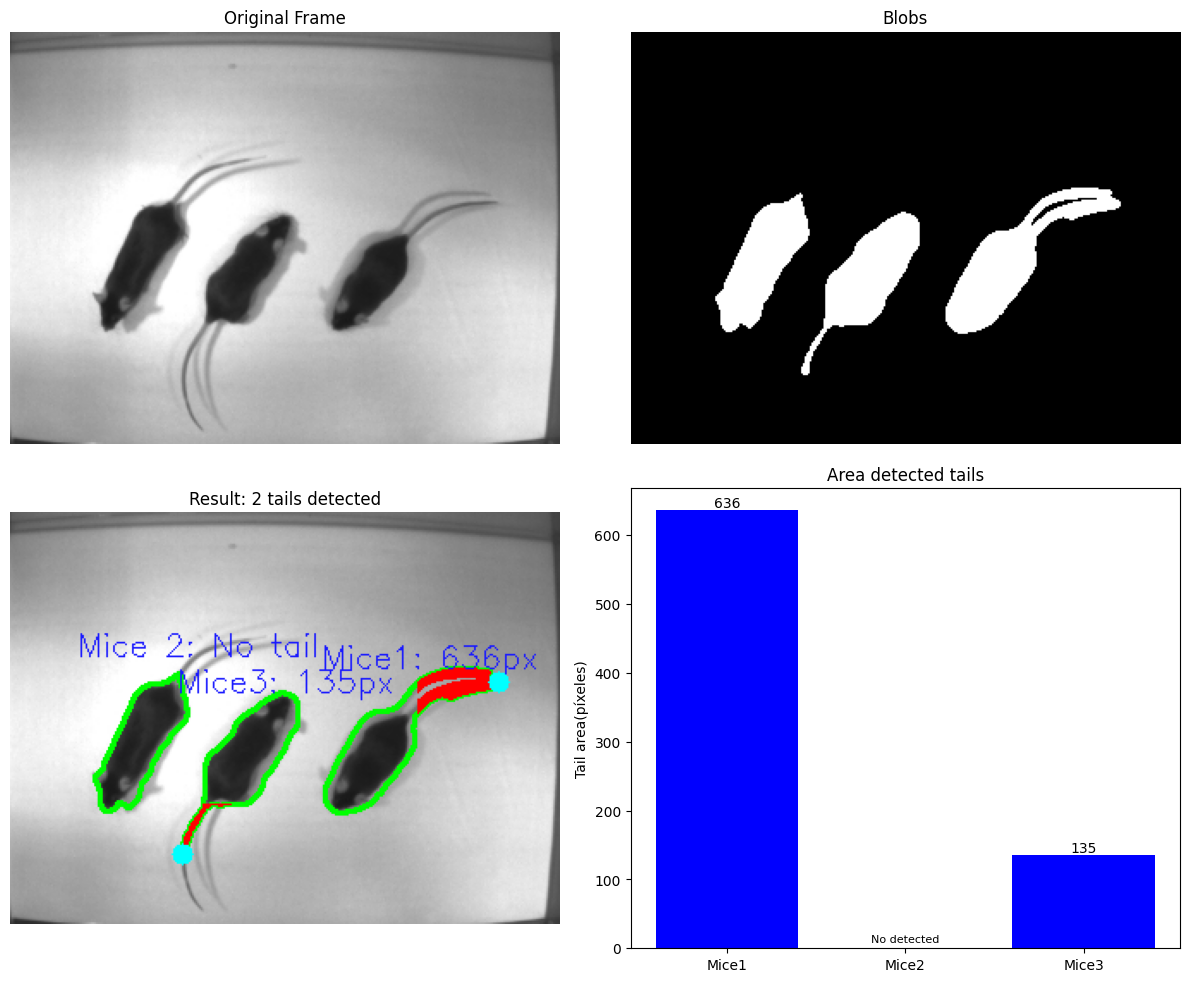


RESUMEN DE ANÁLISIS DE COLAS
Ratón 1: ✓ COLA DETECTADA
  - Área de cola: 636 px
  - Porcentaje: 22.88%
Ratón 2: ✗ SIN COLA
Ratón 3: ✓ COLA DETECTADA
  - Área de cola: 135 px
  - Porcentaje: 5.86%

Total: 2/3 ratones con cola detectada

Análisis completado para 3 ratones


In [55]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

class SimpleMouseTailAnalyzer:
    def __init__(self):
        self.min_mouse_area = 600
        self.max_mouse_area = 7000
        self.min_tail_area = 50
        self.max_tail_area = 600

    def preprocess_image(self, ruta_carpeta, ruta_imagen):
        """Carga y preprocesa la imagen"""
        # Cargar imagen
        frame = read_image(0,ruta_carpeta, ruta_imagen)
        clean_frame = clean_image(frame)
        frame_erode = cv.morphologyEx(clean_frame, cv.MORPH_DILATE, kernel_3, iterations = 1)  
#        opening = cv.morphologyEx(frame_erode, cv.MORPH_OPEN, kernel_3, iterations = 2)
        
        return frame, frame_erode
    
    def find_all_mice(self, binary_mask):
        """Encuentra todos los componentes conectados que podrían ser ratones"""
        num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
            binary_mask, connectivity=8
        )
        
        mice_masks = []
        mice_stats = []
        mice_centroids = []
        
        for i in range(1, num_labels):
            area = stats[i, cv2.CC_STAT_AREA]
            if self.min_mouse_area <= area <= self.max_mouse_area:
                mouse_mask = (labels == i).astype(np.uint8) * 255
                mice_masks.append(mouse_mask)
                mice_stats.append(stats[i])
                mice_centroids.append(centroids[i])
        
        return mice_masks, mice_stats, mice_centroids
    
    def find_tail_simple(self, mouse_mask):
        """Encuentra la cola usando un método simple basado en contornos"""
        # Encontrar contornos
        contours, _ = cv2.findContours(mouse_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if not contours:
            return None, None
        
        main_contour = max(contours, key=cv2.contourArea)
        #print(main_contour)
        
        # Método 1: Buscar puntos lejanos del centroide
#        tail_mask = self.find_tail_by_far_points(mouse_mask, main_contour)
        
        # Método 2: Buscar regiones alargadas
#        if tail_mask is None or np.sum(tail_mask) == 0:
    #        tail_mask = self.find_tail_by_elongation(mouse_mask)

        # Método 3: Buscar puntos lejanos del centroide y luego regiones alargadas
        tail_end_point, tail_mask = self.find_tail_by_elongation_far_points(mouse_mask, main_contour)   
        
        return tail_end_point, tail_mask, main_contour
    
    def find_tail_by_elongation_far_points(self, mouse_mask, contour):
        """Encuentra la cola buscando puntos lejanos del centroide"""
        # Calcular centroide del contorno
        M = cv2.moments(contour)
        if M["m00"] == 0:
            return None
            
        cx = int(M["m10"] / M["m00"])
        cy = int(M["m01"] / M["m00"])
        
        # Encontrar el punto más lejano del centroide
        contour_points = contour.reshape(-1, 2)
        distances = np.sqrt((contour_points[:, 0] - cx)**2 + (contour_points[:, 1] - cy)**2)
        farthest_idx = np.argmax(distances)
        farthest_point = contour_points[farthest_idx]
        
        # Crear una región alrededor del punto más lejano
        tail_mask = np.zeros_like(mouse_mask)
        x, y = farthest_point
        
        # Definir el tamaño de la región a explorar
        initial_region_size = 35
        region_size = initial_region_size
        region_increment = 6
        min_aspect_ratio = 1.7
        best_aspect_ratio = 0.0

        # Optimización: expandir la región hasta encontrar el cuerpo o salir si no es alargada
        while True  :
            x1 = max(0, x - region_size)
            x2 = min(mouse_mask.shape[1], x + region_size)
            y1 = max(0, y - region_size)
            y2 = min(mouse_mask.shape[0], y + region_size)

            # Extraer la región de interés
            roi = mouse_mask[y1:y2, x1:x2]
                # Encontrar componentes conectados en la ROI
            num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(roi, connectivity=8)
                    # Buscar el componente que contiene el punto lejano (relativo a la ROI)
            #best_tail = None
            print(f"Found {num_labels} labels in region size")
#            for i in range(1, num_labels):
            i = num_labels - 1  # Solo analizar el último componente (el más grande)
            area = stats[i, cv2.CC_STAT_AREA]
            print("Analyzing label", i, "with area", area )
            # Filtrar por área
            if self.min_tail_area <= area <= self.max_tail_area:
                # Calcular relación de aspecto
                width = stats[i, cv2.CC_STAT_WIDTH]
                height = stats[i, cv2.CC_STAT_HEIGHT]
             # Evitar división por cero
                if min(width, height) > 0:
                    aspect_ratio = max(width, height) / min(width, height)
                    print("Aspect ratio:", aspect_ratio)    
                 # Si es muy alargado, podría ser la cola
                    if aspect_ratio >= min_aspect_ratio:
#                        component_mask = (labels == i).astype(np.uint8) * 255
#                        best_tail = component_mask
                        best_aspect_ratio = aspect_ratio
                        #aumentamos la roi para buscar más pixeles estrechos
                        print("cola encontrada, aumentando roi...")
                        region_size += region_increment
                    elif aspect_ratio < min_aspect_ratio :
                        # si no es alargado, salimos del bucle
                        region_size -= region_increment
                        print("cola deja de ser alargada, saliendo...  ")
                        break
                else:
                    # si min(width, height) es 0, salimos del bucle
                    print("min(width, height) es 0")
                    break
            else:
                # si no está en el rango de área, salimos del bucle
                print("label too small or too big, exiting...")
                if(region_size == initial_region_size):
                    print("ROI is not a tail")
                    return farthest_point, np.zeros_like(mouse_mask)
                break   
            if(region_size > 100):
                print("region size exceeded limit, exiting...")
                break
        print("best aspect ratio:", best_aspect_ratio)
        print("final region size:", region_size)

        x1 = max(0, x - region_size)
        x2 = min(mouse_mask.shape[1], x + region_size)
        y1 = max(0, y - region_size)
        y2 = min(mouse_mask.shape[0], y + region_size)
        roi = mouse_mask[y1:y2, x1:x2]

        num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(roi, connectivity=8)
        
        # Buscar el componente que contiene el punto lejano (relativo a la ROI)
        local_x = x - x1
        local_y = y - y1

        roi = mouse_mask[y1:y2, x1:x2]
      
        if 0 <= local_x < roi.shape[1] and 0 <= local_y < roi.shape[0]:
            if roi[local_y, local_x] > 0:
                label_idx = labels[local_y, local_x]
                if label_idx > 0:
                    # Crear máscara para este componente
                    component_mask = (labels == label_idx).astype(np.uint8) * 255
                    tail_mask[y1:y2, x1:x2] = component_mask
     # Verificar si es una cola válida
        if self.is_valid_tail(tail_mask):
            return farthest_point, tail_mask
        # Encontrar componentes conectados en las partes delgadas
           
        return farthest_point, tail_mask

        

    def find_tail_by_far_points(self, mouse_mask, contour):
        """Encuentra la cola buscando puntos lejanos del centroide"""
        # Calcular centroide del contorno
        M = cv2.moments(contour)
        if M["m00"] == 0:
            return None
            
        cx = int(M["m10"] / M["m00"])
        cy = int(M["m01"] / M["m00"])
        
        # Encontrar el punto más lejano del centroide
        contour_points = contour.reshape(-1, 2)
        distances = np.sqrt((contour_points[:, 0] - cx)**2 + (contour_points[:, 1] - cy)**2)
        farthest_idx = np.argmax(distances)
        farthest_point = contour_points[farthest_idx]
        
        # Crear una región alrededor del punto más lejano
        tail_mask = np.zeros_like(mouse_mask)
        x, y = farthest_point
        
        # Definir el tamaño de la región a explorar
        region_size = 40
        x1 = max(0, x - region_size)
        x2 = min(mouse_mask.shape[1], x + region_size)
        y1 = max(0, y - region_size)
        y2 = min(mouse_mask.shape[0], y + region_size)
        
        # Extraer la región de interés
        roi = mouse_mask[y1:y2, x1:x2]
        
        # Encontrar componentes conectados en la ROI
        num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(roi, connectivity=8)
        
        # Buscar el componente que contiene el punto lejano (relativo a la ROI)
        local_x = x - x1
        local_y = y - y1
        
        if 0 <= local_x < roi.shape[1] and 0 <= local_y < roi.shape[0]:
            if roi[local_y, local_x] > 0:
                label_idx = labels[local_y, local_x]
                if label_idx > 0:
                    # Crear máscara para este componente
                    component_mask = (labels == label_idx).astype(np.uint8) * 255
                    tail_mask[y1:y2, x1:x2] = component_mask
                    
                    # Verificar si es una cola válida
                    if self.is_valid_tail(tail_mask):
                        return tail_mask
        
        return None
    
    def find_tail_by_elongation(self, mouse_mask):
        """Encuentra la cola buscando regiones alargadas"""
        # Aplicar erosión para encontrar partes delgadas
        kernel = np.ones((3, 3), np.uint8)
        eroded = cv2.erode(mouse_mask, kernel, iterations=1)
        thin_parts = mouse_mask# - eroded
        
        # Encontrar componentes conectados en las partes delgadas
        num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(thin_parts, connectivity=8)
        
        best_tail = None
        best_aspect_ratio = 0
        
        for i in range(1, num_labels):
            area = stats[i, cv2.CC_STAT_AREA]
            
            # Filtrar por área
            if self.min_tail_area <= area <= self.max_tail_area:
                # Calcular relación de aspecto
                width = stats[i, cv2.CC_STAT_WIDTH]
                height = stats[i, cv2.CC_STAT_HEIGHT]
                
                # Evitar división por cero
                if min(width, height) > 0:
                    aspect_ratio = max(width, height) / min(width, height)
                    
                    # Si es muy alargado, podría ser la cola
                    if aspect_ratio > 2.5 and aspect_ratio > best_aspect_ratio:
                        component_mask = (labels == i).astype(np.uint8) * 255
                        best_tail = component_mask
                        best_aspect_ratio = aspect_ratio
        
        return best_tail
    
    def is_valid_tail(self, tail_mask):
        """Verifica si la máscara de cola es válida"""
        if tail_mask is None:
            return False
            
        area = np.sum(tail_mask > 0)
        return self.min_tail_area <= area <= self.max_tail_area
    
    def calculate_tail_area(self, tail_mask):
        """Calcula el área de la cola en píxeles"""
        return np.sum(tail_mask > 0) if tail_mask is not None else 0
    
    def analyze_all_mice_tails(self, ruta_carpeta, ruta_imagen, show_results=True):
        """Función principal que ejecuta el análisis para todos los ratones"""
        original, binary_mask = self.preprocess_image(ruta_carpeta, ruta_imagen)
        mice_masks, mice_stats, mice_centroids = self.find_all_mice(binary_mask)
        
        if not mice_masks:
            print("No se pudieron encontrar ratones en la imagen")
            return None
        
        print(f"Se encontraron {len(mice_masks)} ratones en la imagen")
        
        results = []
        visualization_data = []
        
        for i, (mouse_mask, stats, centroid) in enumerate(zip(mice_masks, mice_stats, mice_centroids)):
            print(f"Analizando ratón {i+1}...")
            
            tail_end_point, tail_mask, main_contour = self.find_tail_simple(mouse_mask)
            tail_area = self.calculate_tail_area(tail_mask)
            
            mouse_result = {
                'mouse_id': i + 1,
                'tail_area_pixels': tail_area,
                'total_mouse_area': stats[cv2.CC_STAT_AREA],
                'tail_percentage': (tail_area / stats[cv2.CC_STAT_AREA]) * 100 if stats[cv2.CC_STAT_AREA] > 0 else 0,
                'centroid': centroid,
                'bounding_box': {
                    'x': stats[cv2.CC_STAT_LEFT],
                    'y': stats[cv2.CC_STAT_TOP],
                    'width': stats[cv2.CC_STAT_WIDTH],
                    'height': stats[cv2.CC_STAT_HEIGHT]
                },
                'has_tail': tail_area > 0,
                'tail_end_point': tail_end_point
            }
            
            results.append(mouse_result)
            visualization_data.append({
                'mouse_mask': mouse_mask,
                'tail_mask': tail_mask,
                'contour': main_contour
            })
        
        if show_results:
            self.display_results(original, visualization_data, results)
        
        return results
    
    def display_results(self, original, visualization_data, results):
        """Muestra los resultados del análisis"""
        fig, axes = plt.subplots(2, 2, figsize=(12, 10))
        
        # Imagen original
        axes[0, 0].imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
        axes[0, 0].set_title('Original Frame')
        axes[0, 0].axis('off')
        
        # Máscara binaria
        binary_display = np.zeros_like(original[:,:,0])
        for data in visualization_data:
            binary_display = cv2.bitwise_or(binary_display, data['mouse_mask'])
        
        axes[0, 1].imshow(binary_display, cmap='gray')
        axes[0, 1].set_title('Blobs')
        axes[0, 1].axis('off')
        
        # Resultado final
        result_image = original.copy()
        tails_detected = 0
        
        for i, (data, result) in enumerate(zip(visualization_data, results)):
            # Dibujar contorno del ratón
            cv2.drawContours(result_image, [data['contour']], -1, (0, 255, 0), 2)
            
            # Dibujar cola si existe
            if data['tail_mask'] is not None and result['has_tail']:
                tail_coords = np.where(data['tail_mask'] > 0)
                result_image[tail_coords[0], tail_coords[1]] = [0, 0, 255]  # Rojo
                tails_detected += 1
                
                # Añadir información
                bbox = result['bounding_box']
                text = f"Mice{result['mouse_id']}: {result['tail_area_pixels']}px"
                cv2.putText(result_image, text, 
                           (int(bbox['x'])-2, int(bbox['y'])),
                           cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 25, 25), 1)
                cv2.circle(result_image, (int(result['tail_end_point'][0]), int(result['tail_end_point'][1])), 6, (255, 255, 0),-1)  # Punto final de
            else:
                # Dibujar solo el ID si no tiene cola
                bbox = result['bounding_box']
                text = f"Mice {result['mouse_id']}: No tail"
                cv2.putText(result_image, text, 
                           (int(bbox['x'])-10, int(bbox['y'] - 10)),
                           cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 25, 25), 1)
        
        axes[1, 0].imshow(cv2.cvtColor(result_image, cv2.COLOR_BGR2RGB))
        axes[1, 0].set_title(f'Result: {tails_detected} tails detected')
        axes[1, 0].axis('off')
        
        # Gráfico de áreas
        mouse_ids = [f"Mice{result['mouse_id']}" for result in results]
        tail_areas = [result['tail_area_pixels'] for result in results]
        
        colors = ['red' if area == 0 else 'blue' for area in tail_areas]
        bars = axes[1, 1].bar(mouse_ids, tail_areas, color=colors)
        axes[1, 1].set_ylabel('Tail area(píxeles)')
        axes[1, 1].set_title('Area detected tails')
        
        # Añadir valores en las barras
        for bar, area in zip(bars, tail_areas):
            height = bar.get_height()
            if height > 0:
                axes[1, 1].text(bar.get_x() + bar.get_width()/2., height,
                               f'{area}', ha='center', va='bottom')
            else:
                axes[1, 1].text(bar.get_x() + bar.get_width()/2., height + 5,
                               'No detected', ha='center', va='bottom', fontsize=8)
        
        plt.tight_layout()
        plt.show()
        
        # Imprimir resumen
        self.print_summary(results)
    
    def print_summary(self, results):
        """Imprime un resumen de los resultados"""
        print("\n" + "="*50)
        print("RESUMEN DE ANÁLISIS DE COLAS")
        print("="*50)
        
        tails_found = sum(1 for r in results if r['has_tail'])
        
        for result in results:
            status = "✓ COLA DETECTADA" if result['has_tail'] else "✗ SIN COLA"
            print(f"Ratón {result['mouse_id']}: {status}")
            if result['has_tail']:
                print(f"  - Área de cola: {result['tail_area_pixels']} px")
                print(f"  - Porcentaje: {result['tail_percentage']:.2f}%")
        
        print(f"\nTotal: {tails_found}/{len(results)} ratones con cola detectada")
        print("="*50)

def main():
    analyzer = SimpleMouseTailAnalyzer()
    
    try:
        
        results = analyzer.analyze_all_mice_tails(ruta_carpeta, ruta_imagen)
        
        if results:
            print(f"\nAnálisis completado para {len(results)} ratones")
            
    except Exception as e:
        print(f"\nAnálisis completado para {len(results)} ratones")
        print(f"Error: {e}")

if __name__ == "__main__":
    main()